# Handling numerical data
We have seen how to deal with categorical variables, a common thought colud be "hey, the trouble with categorical values was related with Scikit inability to handle strings and booleans, so quantitative values are numbers then there is not trouble". That's true, you can train your models using the data as it comes from the dataset, but some considerations could improve models performance. In this guide I'm going to review most common numerical data preprocessing considerations to avoid performance downgrades.

## Scaling
Scaling works moving variables values to a desired range or scale. Doesn't changes variable distribution (neither works for treating skewness) or minimizes outliner effects.

### Standarization
Transforms feature values to an approximation of 
standard distribution (a normal distribution with mean 0 and standard deviation of 1). Works calculating the Z-score of the value.

<center>
    $Z = \frac{x - \mu}{\sigma}$
</center>


**Advantages:**
- Works fine when data almost follows a Gaussian distribution
- useful when there are many numerical variables different (to avoid biased calculations because a variable is taken as significant just for having values higher than others).
- Some ML techniques requires centered data or assumes data follows a normal distribution to perform well.

**Disadvantages:**
- Sensitive to outliners.
- On skewed distributions doesn't performs well.
- Just centers the data close to the mean.
- Values aren't bounded to a range.

In [1]:
from sklearn.preprocessing import StandardScaler
from pandas import read_csv

DATA = read_csv("/kaggle/input/datasets/debayank2024/house-price-prediction/modified_data.csv")

data = DATA.drop(columns=["date"])

NUMS = ["sqft_living", "bathrooms", "bedrooms", "sqft_lot", "floors"]
CATS = ["waterfront", "view", "condition"]

STANDARD_SCALER = StandardScaler()
STANDARD_SCALER.set_output(transform="pandas")

transformed_data = STANDARD_SCALER.fit_transform(data[NUMS])

transformed_data.head()

,sqft_living,bathrooms,bedrooms,sqft_lot,floors
0,-0.829971,-0.843204,-0.441122,-0.193434,-0.022416
1,1.568528,0.432802,1.759705,-0.161718,0.906555
2,-0.217367,-0.205201,-0.441122,-0.080978,-0.951388
3,-0.144686,0.113800,-0.441122,-0.190145,-0.951388
4,-0.206984,0.432802,0.659291,-0.121306,-0.951388


### Min-max scaling
Scales numerical data to $[0, 1]$ range calculating the rate between distance from the min value to a value by the range width of the variable.

<center>
    $x' = \frac{x-x_{min}}{x_{max}-x_{min}}$
</center>


**Advantages:**
- Holds relative order.
- Every features stays in a comparable scale.
- Useful when you need a bounded range.

**Disadvantages:**
- More sensitive to outliners than standard scaling.
- Negative values can appear with unseen data.
- Unseen outliners can be out of the range.

In [2]:
from sklearn.preprocessing import MinMaxScaler

MINMAX_SCALER = MinMaxScaler()
MINMAX_SCALER.set_output(transform="pandas")

transformed_data = MINMAX_SCALER.fit_transform(data[NUMS])

transformed_data.head()

,sqft_living,bathrooms,bedrooms,sqft_lot,floors
0,0.073652,0.18750,0.333333,0.006775,0.2
1,0.249051,0.31250,0.555556,0.007835,0.4
2,0.118451,0.25000,0.333333,0.010534,0.0
3,0.123766,0.28125,0.333333,0.006885,0.0
4,0.119210,0.31250,0.444444,0.009186,0.0


### Robust scaling
This is an enhancement of standard scaler, is perfect when working with datasets containing many outliners.

<center>
    $x' = \frac{x-Q_{2}}{Q_{3}-Q_{1}}$
</center>

**Advantages:**
- A good alternative to standarization.
- Tough to outliners.
- Some ML techniques requires centered data or assumes data follows a normal distribution to perform well.

**Disadvantages:**
- Doesn't removes outliners.
- Not recommended when data follows a normal distribution and there isn't outliners.

In [3]:
from sklearn.preprocessing import RobustScaler

ROBUST_SCALER = RobustScaler()
ROBUST_SCALER.set_output(transform="pandas")

transformed_data = ROBUST_SCALER.fit_transform(data[NUMS])

transformed_data.head()

,sqft_living,bathrooms,bedrooms,sqft_lot,floors
0,-0.551724,-1.000000,0.0,0.038163,0.0
1,1.439655,0.333333,2.0,0.227814,0.5
2,-0.043103,-0.333333,0.0,0.710607,-0.5
3,0.017241,0.000000,0.0,0.057829,-0.5
4,-0.034483,0.333333,1.0,0.469461,-0.5


### Max-abs scaling
Divides each variable by the maximun absolute value of the variable.

<center>
    $x' = \frac{x}{max(|x|)}$
</center>

**Advantages:**
- Nice choice on sparse data.
- Values are almost bounded to $[-1, 1]$ range.

**Disadvantages:**
- It assumed that features are centered to 0.
- Only performs well on sparse data.

In [4]:
from sklearn.preprocessing import MaxAbsScaler

MAXABS_SCALER = MaxAbsScaler()
MAXABS_SCALER.set_output(transform="pandas")

transformed_data = MAXABS_SCALER.fit_transform(data[NUMS])

transformed_data.head()

,sqft_living,bathrooms,bedrooms,sqft_lot,floors
0,0.098966,0.18750,0.333333,0.007365,0.428571
1,0.269572,0.31250,0.555556,0.008425,0.571429
2,0.142541,0.25000,0.333333,0.011122,0.285714
3,0.147710,0.28125,0.333333,0.007475,0.285714
4,0.143279,0.31250,0.444444,0.009775,0.285714


## Transforming variable distributions
As we saw at the previous section, scaling is a way to make our data suitable for some ML algorithms like KNN, linear regression or SVM. However, sometimes data requires more efforts at preprocessing due we have many outliners or data is heavily skewed. In these cases is necessary to transform variable distributions to achieve the best possible performance.

### Power transform
When our variables must follow a Gaussian distribution to stabilize their variance and minimize skewness. Also reduces the negative effect of heavy outliners The most common approaches are "Box-Cox" anb "Yeo-Johnson" transformings.

- **Box-Cox:** Can only be applied to strictly possitive values (without including 0).
- **Yeo-Johnson:** Works for every value.

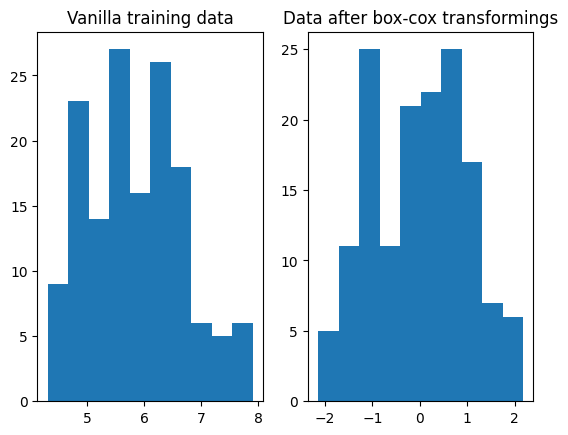

In [5]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt

X, y = load_iris(return_X_y=True)

# Available values are "box-cox" and "yeo-johnson", by default it standarizes the data
power_transformer = PowerTransformer(method="box-cox", standardize=True)
X_trans = power_transformer.fit_transform(X)

fig, axs = plt.subplots(1, 2)

axs[0].hist(X[:, 0], histtype="barstacked", align="mid")
axs[0].set_title("Vanilla training data")


axs[1].hist(X_trans[:, 0], histtype="barstacked", align="mid")
axs[1].set_title("Data after box-cox transformings")

plt.show()

### Quantile transformings
Power transformings follows a formula to transform values, in the opposite side we got quantile transformations. As the name suggests, maps the data to it quantiles reshaping the data to follow an uniform distribution or even into a Gaussian distribution. Advantages are related with reducing outliners effect because doesn't cares if a distribution is heavily skewed, this method tries to transform a variable to a desired distribution.

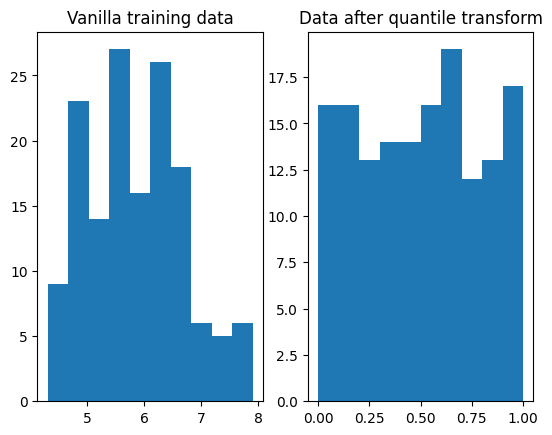

In [6]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import QuantileTransformer
import matplotlib.pyplot as plt

X, y = load_iris(return_X_y=True)

# Distribution can be Gaussian or uniform
# We can set the amount of quantiles used to perform transformings
quantile_transformer = QuantileTransformer(n_quantiles=100, output_distribution="uniform", random_state=123)
X_trans = quantile_transformer.fit_transform(X)

fig, axs = plt.subplots(1, 2)

axs[0].hist(X[:, 0], histtype="barstacked", align="mid")
axs[0].set_title("Vanilla training data")


axs[1].hist(X_trans[:, 0], histtype="barstacked", align="mid")
axs[1].set_title("Data after quantile transform")

plt.show()

## Discretization
This technique is a way to partition continuous features into discrete values. Some datasets and ML algorithms (like Naive Bayes) leverage from this method because it spreads skewed values uniformly across value range. Also outliner's influence is minimized because usually they are placed in the same bin. But as we are changing variables values so we got some information loss because we could be grouping unrelated values in the same bin, so the model could find a relationship with a category value. However, maybe this is not true on raw values.  

There are some strategies to define intervals, Scikit implements the following ones:
- **Uniform:** Every bin in each feature have identical widths.
- **Quantile:** All bins in each feature have the same number of instances.
- **K-Means:** Performs bins classification using K-Means algorithm with a 1D-cluster to place instances into the bins.

Be careful! Scikit returns values as one hot vectors by default, to be more comfortable you can set encoding value into an ordinal format (returns the ID bin that a value belongs to).

In [7]:
from sklearn.preprocessing import KBinsDiscretizer

est = KBinsDiscretizer(encode="ordinal", random_state=123)
est.set_output(transform="pandas")

x_bins = est.fit_transform(DATA[NUMS])

x_bins.head()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(


,sqft_living,bathrooms,bedrooms,sqft_lot,floors
0,0.0,1.0,1.0,2.0,0.0
1,4.0,3.0,2.0,3.0,1.0
2,2.0,2.0,1.0,3.0,0.0
3,2.0,2.0,1.0,2.0,0.0
4,2.0,3.0,2.0,3.0,0.0


## Polynomial features
At the end of this guide, we got a feature engineering strategy, aimed to add complexity to simple models like linear regression. It consists on building polynomial terms for a desired degree from variables values. For instance, if we got a 2 features dataset as the following vector:

<center>
    $\vec{x}=(x_{1}, x_{2})$
</center>

and we want to add polynomial features from a 2 degree polynomial, resulting vector will have the following shape:

<center>
    $\vec{x}'=(x_{1}, x_{2}, x_{1}^{2}, x_{1}x_{2}, x_{2}^{2})$
</center>

From 2 features, we are creating 3 news, that's powerful because includes interaction terms (like $x_{1}x_{2}$) among variables. Works fine when a linear models underfits the data or when the output is nonlinear, specially in regression tasks.  
The main disadvantage is its performance trade-offs because on high degree polynomials perform calculations comes complex and adds many features, also regularization techniques like Lasso or Ridge will be necessary to avoid overfitting. Even, noisy data can cause overfitting, so this approach is recommended for linear and simple models, other techniques like SVM, decision trees, random forests, KNN or neural networks can capture underlying nonlinear relationships between features.

In [8]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer
X = np.arange(6).reshape(3, 2)

# Always generates a 1 as independent coefficient
poly = PolynomialFeatures(2)
poly_coefficients = poly.fit_transform(X)

print("Polynomial features:\n", poly_coefficients)

# Splines are faster than pure polynomial features also
# are flexible and robust when a small degree is chosen,
# doesn't suffers oscilatory behaviour (as high degree polynomials does) and
# are better than regular polynomials when interpolation or extrapolation is needed
spline = SplineTransformer(degree=2, n_knots=3)
spline_coefficients = spline.fit_transform(np.arange(5).reshape(5, 1))

print("\nSpline features:\n", spline_coefficients)

Polynomial features:
 [[ 1.  0.  1.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.]
 [ 1.  4.  5. 16. 20. 25.]]

Spline features:
 [[0.5   0.5   0.    0.   ]
 [0.125 0.75  0.125 0.   ]
 [0.    0.5   0.5   0.   ]
 [0.    0.125 0.75  0.125]
 [0.    0.    0.5   0.5  ]]
